In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer

In [125]:
df_data=pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv")

# Define Problem Statement and perform Exploratory Data Analysis.

### Problem Statement: To predict whether a driver will be leaving the company or not based on their attributes like demographics (city, age, gender etc.),tenure information (joining date, Last Date) and historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

# Basic data cleaning and exploration

In [129]:
df_data.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [130]:
df_data.head(5)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [131]:
df_data.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [132]:
df_data = df_data.drop(['Unnamed: 0'], axis=1)

In [133]:
df_data['MMM-YY'] = pd.to_datetime(df_data['MMM-YY'])


In [134]:
df_data.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,2019-01-01,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,2019-02-01,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,2020-11-01,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [135]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  object        
 8   LastWorkingDate       1616 non-null   object        
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: datetime64[ns

# Feature Engineering

In [136]:
df_new=df_data.groupby('Driver_ID').agg({'Age':'first','Gender':'first','City':'first','Education_Level':'first','Income':'last','Joining Designation':'first','Grade':'last','Dateofjoining':'first','LastWorkingDate':'last','Total Business Value':'sum','Quarterly Rating':'last'}).reset_index()
df_new

,Driver_ID,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Total Business Value,Quarterly Rating
0,1,28.0,0.0,C23,2,57387,1,1,24/12/18,03/11/19,1715580,2
1,2,31.0,0.0,C7,2,67016,2,2,11/06/20,None,0,1
2,4,43.0,0.0,C13,2,65603,2,2,12/07/19,27/04/20,350000,1
3,5,29.0,0.0,C9,0,46368,1,1,01/09/19,03/07/19,120360,1
4,6,31.0,1.0,C11,1,78728,3,3,31/07/20,None,1265000,2
...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,33.0,0.0,C24,0,82815,2,3,15/10/15,None,21748820,4
2377,2785,34.0,1.0,C9,0,12105,1,1,28/08/20,28/10/20,0,1
2378,2786,44.0,0.0,C19,0,35370,2,2,31/07/18,22/09/19,2815090,1
2379,2787,28.0,1.0,C20,2,69498,1,1,21/07/18,20/06/19,977830,1


In [137]:
df_rating_first=df_data.groupby('Driver_ID').agg({'Quarterly Rating':'first'}).reset_index()
df_rating_first.columns = df_rating_first.columns.str.replace('Quarterly Rating', 'Quarterly_Rating_first')
df_rating_first

,Driver_ID,Quarterly_Rating_first
0,1,2
1,2,1
2,4,1
3,5,1
4,6,1
...,...,...
2376,2784,3
2377,2785,1
2378,2786,2
2379,2787,2


In [138]:
df_rating_last=df_data.groupby('Driver_ID').agg({'Quarterly Rating':'last'}).reset_index()
df_rating_last.columns=df_rating_last.columns.str.replace('Quarterly Rating', 'Quarterly_Rating_last')
df_rating_last

,Driver_ID,Quarterly_Rating_last
0,1,2
1,2,1
2,4,1
3,5,1
4,6,2
...,...,...
2376,2784,4
2377,2785,1
2378,2786,1
2379,2787,1


In [139]:
df_rating=pd.merge(df_rating_first,df_rating_last)
df_rating

,Driver_ID,Quarterly_Rating_first,Quarterly_Rating_last
0,1,2,2
1,2,1,1
2,4,1,1
3,5,1,1
4,6,1,2
...,...,...,...
2376,2784,3,4
2377,2785,1,1
2378,2786,2,1
2379,2787,2,1


In [140]:
df_rating['Inc_Quarterly_Rating']=df_rating['Quarterly_Rating_last']-df_rating['Quarterly_Rating_first']
#df_rating=df_rating['Quarterly_Rating_first']-df_rating['Quarterly_Rating_last']
df_rating

,Driver_ID,Quarterly_Rating_first,Quarterly_Rating_last,Inc_Quarterly_Rating
0,1,2,2,0
1,2,1,1,0
2,4,1,1,0
3,5,1,1,0
4,6,1,2,1
...,...,...,...,...
2376,2784,3,4,1
2377,2785,1,1,0
2378,2786,2,1,-1
2379,2787,2,1,-1


In [141]:
df_monthly_first=df_data.groupby('Driver_ID').agg({'Income':'first'}).reset_index()
df_monthly_last=df_data.groupby('Driver_ID').agg({'Income':'last'}).reset_index()
df_monthly_first.columns=df_monthly_first.columns.str.replace('Income','Starting_Income')
df_monthly_last.columns=df_monthly_last.columns.str.replace('Income','Final_Income')
df_monthly_income=pd.merge(df_monthly_first,df_monthly_last)
df_monthly_income['Increment_Income']=df_monthly_income['Starting_Income']-df_monthly_income['Final_Income']
df_monthly_income

,Driver_ID,Starting_Income,Final_Income,Increment_Income
0,1,57387,57387,0
1,2,67016,67016,0
2,4,65603,65603,0
3,5,46368,46368,0
4,6,78728,78728,0
...,...,...,...,...
2376,2784,82815,82815,0
2377,2785,12105,12105,0
2378,2786,35370,35370,0
2379,2787,69498,69498,0


In [142]:
df_new=df_new.merge(df_rating)
df_new

,Driver_ID,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Total Business Value,Quarterly Rating,Quarterly_Rating_first,Quarterly_Rating_last,Inc_Quarterly_Rating
0,1,28.0,0.0,C23,2,57387,1,1,24/12/18,03/11/19,1715580,2,2,2,0
1,2,31.0,0.0,C7,2,67016,2,2,11/06/20,None,0,1,1,1,0
2,4,43.0,0.0,C13,2,65603,2,2,12/07/19,27/04/20,350000,1,1,1,0
3,5,29.0,0.0,C9,0,46368,1,1,01/09/19,03/07/19,120360,1,1,1,0
4,6,31.0,1.0,C11,1,78728,3,3,31/07/20,None,1265000,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,33.0,0.0,C24,0,82815,2,3,15/10/15,None,21748820,4,3,4,1
2377,2785,34.0,1.0,C9,0,12105,1,1,28/08/20,28/10/20,0,1,1,1,0
2378,2786,44.0,0.0,C19,0,35370,2,2,31/07/18,22/09/19,2815090,1,2,1,-1
2379,2787,28.0,1.0,C20,2,69498,1,1,21/07/18,20/06/19,977830,1,2,1,-1


In [143]:
df_new=df_new.merge(df_monthly_income)
df_new

,Driver_ID,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Total Business Value,Quarterly Rating,Quarterly_Rating_first,Quarterly_Rating_last,Inc_Quarterly_Rating,Starting_Income,Final_Income,Increment_Income
0,1,28.0,0.0,C23,2,57387,1,1,24/12/18,03/11/19,1715580,2,2,2,0,57387,57387,0
1,2,31.0,0.0,C7,2,67016,2,2,11/06/20,None,0,1,1,1,0,67016,67016,0
2,4,43.0,0.0,C13,2,65603,2,2,12/07/19,27/04/20,350000,1,1,1,0,65603,65603,0
3,5,29.0,0.0,C9,0,46368,1,1,01/09/19,03/07/19,120360,1,1,1,0,46368,46368,0
4,6,31.0,1.0,C11,1,78728,3,3,31/07/20,None,1265000,2,1,2,1,78728,78728,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,33.0,0.0,C24,0,82815,2,3,15/10/15,None,21748820,4,3,4,1,82815,82815,0
2377,2785,34.0,1.0,C9,0,12105,1,1,28/08/20,28/10/20,0,1,1,1,0,12105,12105,0
2378,2786,44.0,0.0,C19,0,35370,2,2,31/07/18,22/09/19,2815090,1,2,1,-1,35370,35370,0
2379,2787,28.0,1.0,C20,2,69498,1,1,21/07/18,20/06/19,977830,1,2,1,-1,69498,69498,0


In [144]:

def target(val):  
    if val == None:
        return 0    
    else: 
        return 1

In [145]:
df_new['target'] = df_new.LastWorkingDate.apply(target)
df_new

,Driver_ID,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Total Business Value,Quarterly Rating,Quarterly_Rating_first,Quarterly_Rating_last,Inc_Quarterly_Rating,Starting_Income,Final_Income,Increment_Income,target
0,1,28.0,0.0,C23,2,57387,1,1,24/12/18,03/11/19,1715580,2,2,2,0,57387,57387,0,1
1,2,31.0,0.0,C7,2,67016,2,2,11/06/20,None,0,1,1,1,0,67016,67016,0,0
2,4,43.0,0.0,C13,2,65603,2,2,12/07/19,27/04/20,350000,1,1,1,0,65603,65603,0,1
3,5,29.0,0.0,C9,0,46368,1,1,01/09/19,03/07/19,120360,1,1,1,0,46368,46368,0,1
4,6,31.0,1.0,C11,1,78728,3,3,31/07/20,None,1265000,2,1,2,1,78728,78728,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,33.0,0.0,C24,0,82815,2,3,15/10/15,None,21748820,4,3,4,1,82815,82815,0,0
2377,2785,34.0,1.0,C9,0,12105,1,1,28/08/20,28/10/20,0,1,1,1,0,12105,12105,0,1
2378,2786,44.0,0.0,C19,0,35370,2,2,31/07/18,22/09/19,2815090,1,2,1,-1,35370,35370,0,1
2379,2787,28.0,1.0,C20,2,69498,1,1,21/07/18,20/06/19,977830,1,2,1,-1,69498,69498,0,1


In [146]:
df_new.columns

Index(['Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income',
       'Joining Designation', 'Grade', 'Dateofjoining', 'LastWorkingDate',
       'Total Business Value', 'Quarterly Rating', 'Quarterly_Rating_first',
       'Quarterly_Rating_last', 'Inc_Quarterly_Rating', 'Starting_Income',
       'Final_Income', 'Increment_Income', 'target'],
      dtype='object')

In [147]:
df_new.dtypes

Driver_ID                   int64
Age                       float64
Gender                    float64
City                       object
Education_Level             int64
Income                      int64
Joining Designation         int64
Grade                       int64
Dateofjoining              object
LastWorkingDate            object
Total Business Value        int64
Quarterly Rating            int64
Quarterly_Rating_first      int64
Quarterly_Rating_last       int64
Inc_Quarterly_Rating        int64
Starting_Income             int64
Final_Income                int64
Increment_Income            int64
target                      int64
dtype: object

In [148]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2381 entries, 0 to 2380
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Driver_ID               2381 non-null   int64  
 1   Age                     2381 non-null   float64
 2   Gender                  2381 non-null   float64
 3   City                    2381 non-null   object 
 4   Education_Level         2381 non-null   int64  
 5   Income                  2381 non-null   int64  
 6   Joining Designation     2381 non-null   int64  
 7   Grade                   2381 non-null   int64  
 8   Dateofjoining           2381 non-null   object 
 9   LastWorkingDate         1616 non-null   object 
 10  Total Business Value    2381 non-null   int64  
 11  Quarterly Rating        2381 non-null   int64  
 12  Quarterly_Rating_first  2381 non-null   int64  
 13  Quarterly_Rating_last   2381 non-null   int64  
 14  Inc_Quarterly_Rating    2381 non-null   

In [149]:
df_new.describe()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly_Rating_first,Quarterly_Rating_last,Inc_Quarterly_Rating,Starting_Income,Final_Income,Increment_Income,target
count,2381.000000,2381.000000,2381.000000,2381.00000,2381.000000,2381.000000,2381.000000,2.381000e+03,2381.000000,2381.000000,2381.000000,2381.000000,2381.000000,2381.000000,2381.000000,2381.000000
mean,1397.559009,33.090718,0.410332,1.00756,59334.157077,1.820244,2.096598,4.586742e+06,1.427971,1.486350,1.427971,-0.058379,59209.060899,59334.157077,-125.096178,0.678706
std,806.161628,5.840686,0.491997,0.81629,28383.666384,0.841433,0.941522,9.127115e+06,0.809839,0.834348,0.809839,0.933703,28275.899087,28383.666384,968.511766,0.467071
min,1.000000,21.000000,0.000000,0.00000,10747.000000,1.000000,1.000000,-1.385530e+06,1.000000,1.000000,1.000000,-3.000000,10747.000000,10747.000000,-12155.000000,0.000000
25%,695.000000,29.000000,0.000000,0.00000,39104.000000,1.000000,1.000000,0.000000e+00,1.000000,1.000000,1.000000,0.000000,39104.000000,39104.000000,0.000000,0.000000
50%,1400.000000,33.000000,0.000000,1.00000,55315.000000,2.000000,2.000000,8.176800e+05,1.000000,1.000000,1.000000,0.000000,55276.000000,55315.000000,0.000000,1.000000
75%,2100.000000,37.000000,1.000000,2.00000,75986.000000,2.000000,3.000000,4.173650e+06,2.000000,2.000000,2.000000,0.000000,75765.000000,75986.000000,0.000000,1.000000
max,2788.000000,58.000000,1.000000,2.00000,188418.000000,5.000000,5.000000,9.533106e+07,4.000000,4.000000,4.000000,3.000000,188418.000000,188418.000000,0.000000,1.000000


In [150]:
df_new = df_new.drop(['Dateofjoining','LastWorkingDate'], axis=1)


# Missing Values

In [151]:
df_new.isnull().sum()/len(df_new)*100

Driver_ID                 0.0
Age                       0.0
Gender                    0.0
City                      0.0
Education_Level           0.0
Income                    0.0
Joining Designation       0.0
Grade                     0.0
Total Business Value      0.0
Quarterly Rating          0.0
Quarterly_Rating_first    0.0
Quarterly_Rating_last     0.0
Inc_Quarterly_Rating      0.0
Starting_Income           0.0
Final_Income              0.0
Increment_Income          0.0
target                    0.0
dtype: float64

# Categorical Attributes

In [152]:
cat_cols=df_new.dtypes=='object'
cat_cols=list(cat_cols[cat_cols].index)
cat_cols

['City']

In [153]:
df_new['City'].value_counts()

C20    152
C15    101
C29     96
C26     93
C8      89
C27     89
C10     86
C16     84
C22     82
C3      82
C28     82
C12     81
C5      80
C1      80
C21     79
C14     79
C6      78
C4      77
C7      76
C9      75
C25     74
C23     74
C24     73
C19     72
C2      72
C17     71
C13     71
C18     69
C11     64
Name: City, dtype: int64

# Numeric Attributes

In [154]:
num_cols=df_new.dtypes!='object'
num_cols=list(num_cols[num_cols].index)
num_cols

['Driver_ID',
 'Age',
 'Gender',
 'Education_Level',
 'Income',
 'Joining Designation',
 'Grade',
 'Total Business Value',
 'Quarterly Rating',
 'Quarterly_Rating_first',
 'Quarterly_Rating_last',
 'Inc_Quarterly_Rating',
 'Starting_Income',
 'Final_Income',
 'Increment_Income',
 'target']

In [155]:
df_new['Gender'].value_counts()

0.0    1404
1.0     977
Name: Gender, dtype: int64

In [156]:
df_new['Education_Level'].value_counts()

2    802
1    795
0    784
Name: Education_Level, dtype: int64

In [157]:
df_new['Income'].value_counts()

48747    3
49664    2
56687    2
57225    2
56243    2
        ..
23823    1
42607    1
36846    1
70330    1
70254    1
Name: Income, Length: 2339, dtype: int64

In [158]:
df_new['Joining Designation'].value_counts()

1    1026
2     815
3     493
4      36
5      11
Name: Joining Designation, dtype: int64

In [159]:
df_new['Grade'].value_counts()

2    855
1    741
3    623
4    138
5     24
Name: Grade, dtype: int64

In [160]:
df_new['Total Business Value'].value_counts()

0           719
200000       10
250000        6
350000        5
600000        4
           ... 
13197400      1
3958550       1
303580        1
1066070       1
2298240       1
Name: Total Business Value, Length: 1629, dtype: int64

In [161]:
df_new['Quarterly Rating'].value_counts()

1    1744
2     362
3     168
4     107
Name: Quarterly Rating, dtype: int64

In [162]:
df_new['target'].value_counts()

1    1616
0     765
Name: target, dtype: int64

In [193]:
df_new['Increment_Income'].value_counts()

 0       2181
-5797       1
-6221       1
-3547       1
-6124       1
-6598       1
-3715       1
-5832       1
-6898       1
-5139       1
-4852       1
Name: Increment_Income, dtype: int64

# Univariate Analysis

## Analysis on the distribution of numerical variables

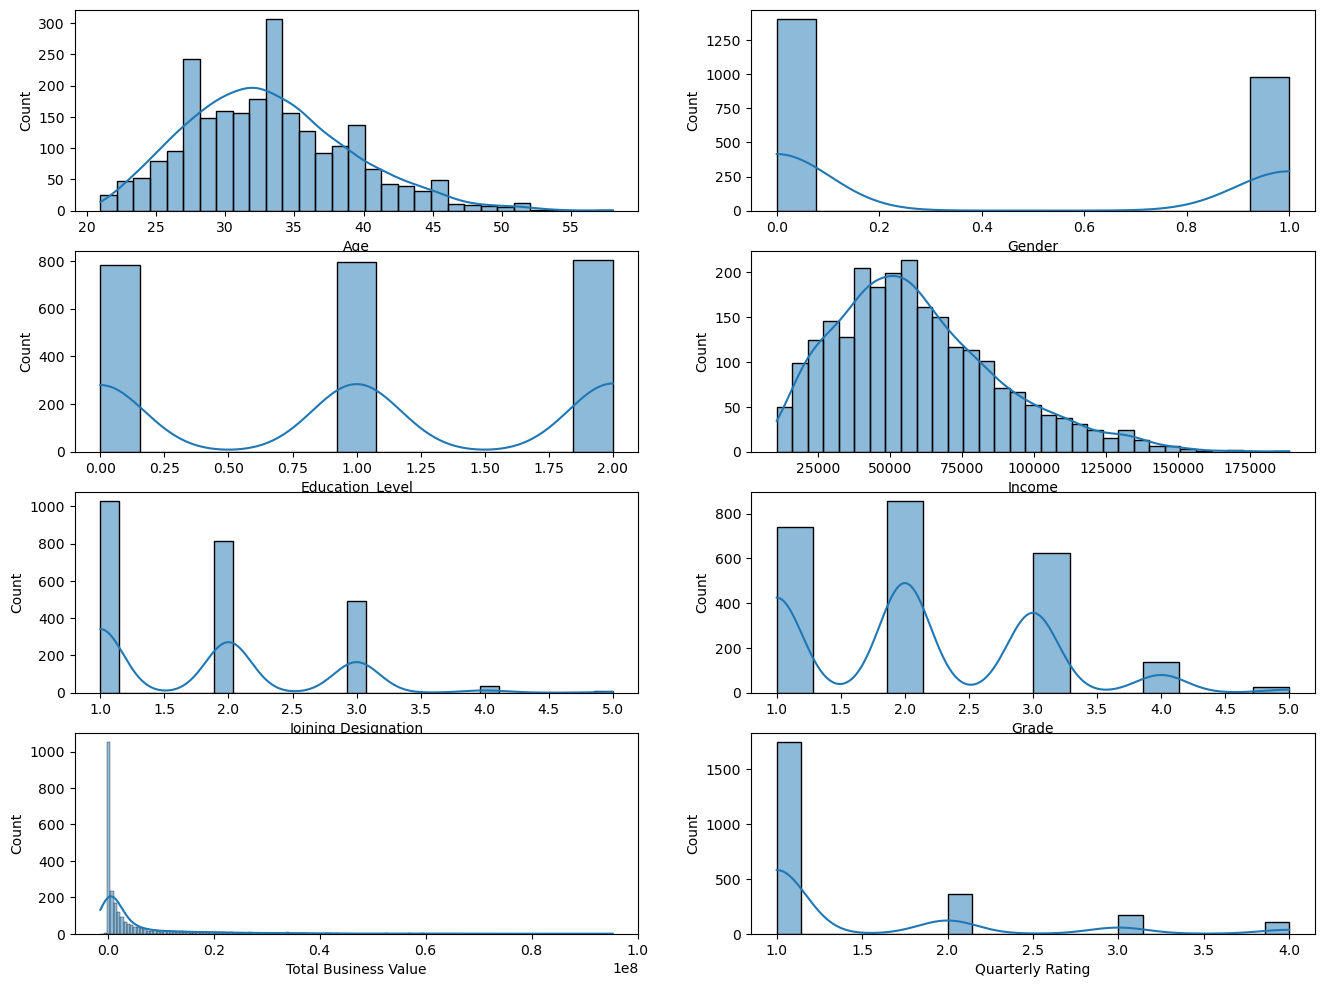

In [163]:
num_attri=['Age','Gender','Education_Level','Income','Joining Designation','Grade','Total Business Value','Quarterly Rating']

fig, axis = plt.subplots(nrows=4, ncols=2, figsize=(16, 12))

i = 0
for row in range(4):
    for col in range(2):
        sns.histplot(df_new[num_attri[i]], ax=axis[row, col], kde=True)
        i += 1
plt.show()

[]

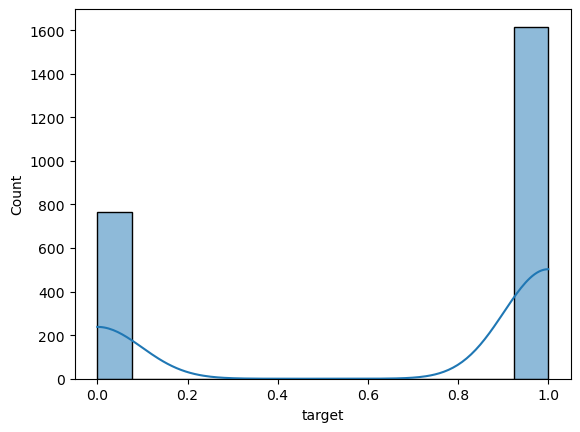

In [164]:
sns.histplot(df_new['target'],kde=True)
plt.plot()

# Outlier Detection

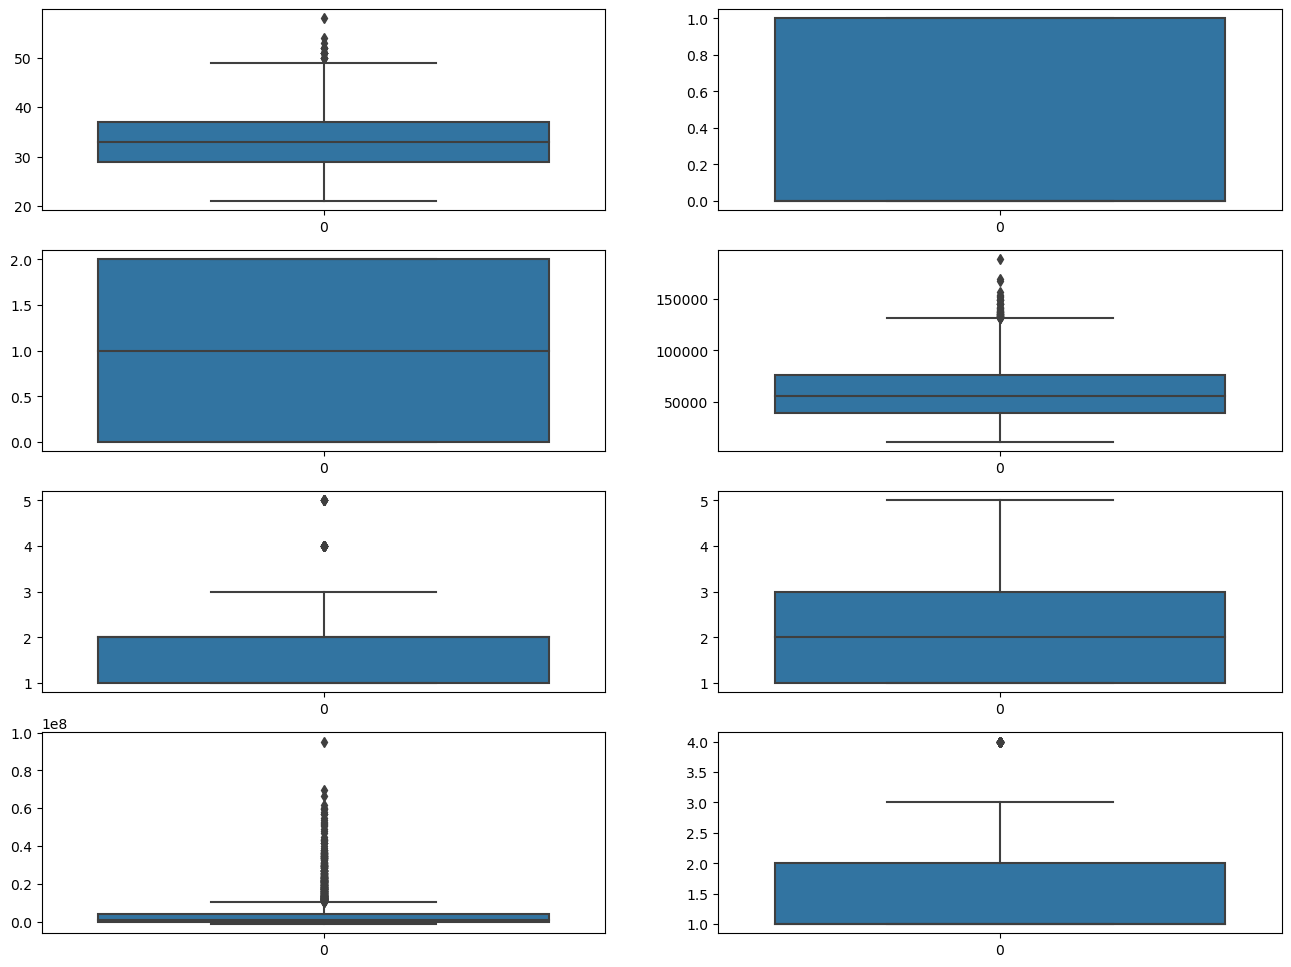

In [165]:

fig, axis = plt.subplots(nrows=4, ncols=2, figsize=(16, 12))

i = 0
for row in range(4):
    for col in range(2):
        sns.boxplot(df_new[num_attri[i]], ax=axis[row, col])
        i += 1
plt.show()

# Bivariate Analysis

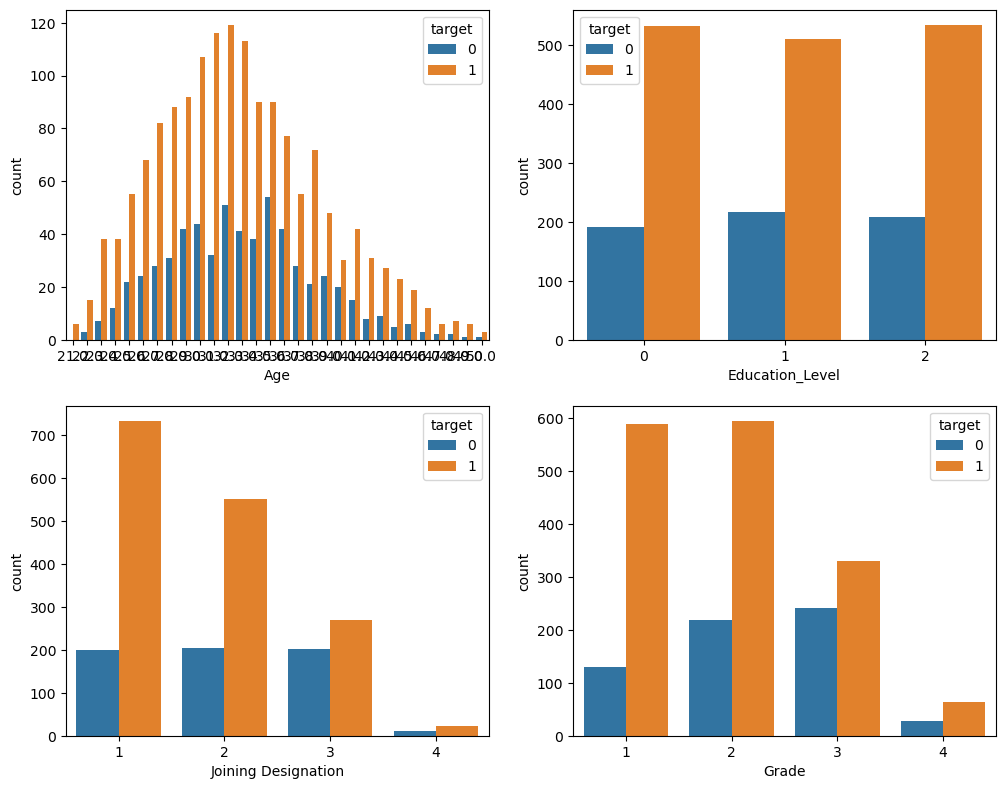

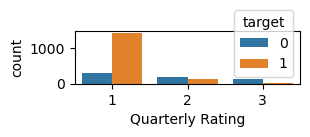

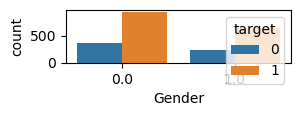

In [189]:
plt.figure(figsize=(12, 30)) 

plt.subplot(6, 2, 1) 
sns.countplot(x='Age', data=df_new, hue='target')

plt.subplot(6, 2, 2) 
sns.countplot(x='Education_Level', data=df_new, hue='target')

plt.subplot(6, 2, 3) 
sns.countplot(x='Joining Designation', data=df_new, hue='target') 

plt.subplot(6, 2, 4) 
sns.countplot(x='Grade', data=df_new, hue='target') 
plt.show()

plt.subplot(6, 2, 5) 
sns.countplot(x='Quarterly Rating', data=df_new, hue='target') 
plt.show()
plt.subplot(6, 2, 6) 
sns.countplot(x='Gender', data=df_new, hue='target') 
plt.show()



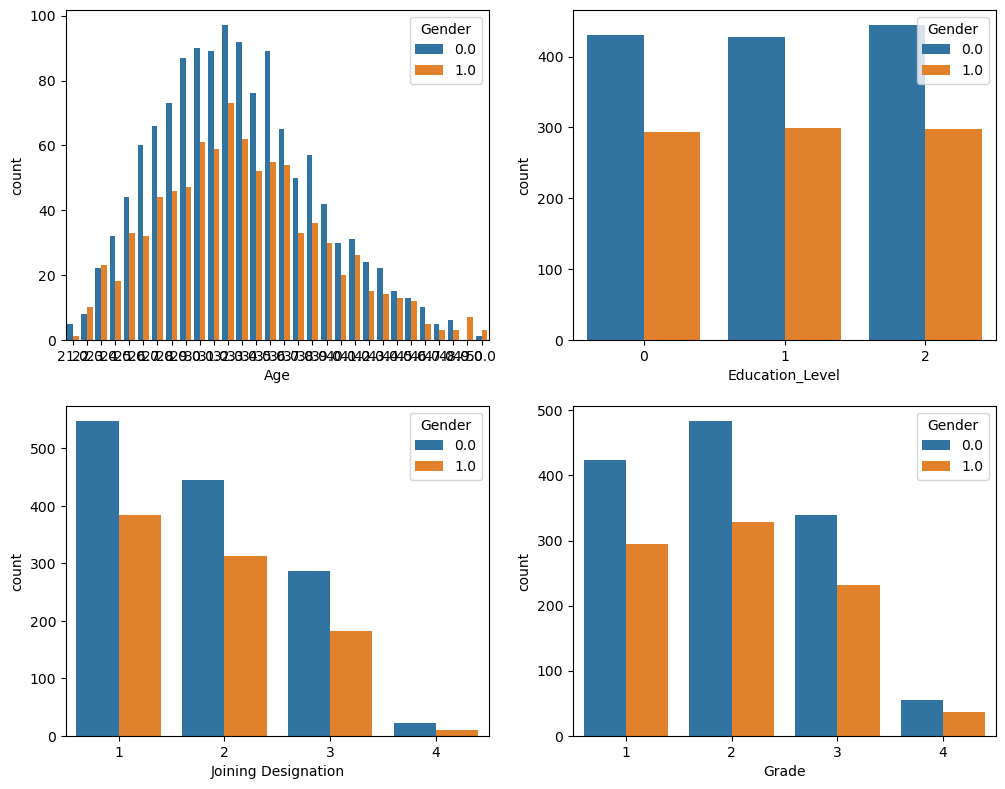

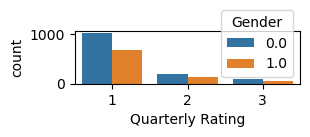

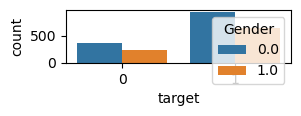

In [191]:
plt.figure(figsize=(12, 30)) 

plt.subplot(6, 2, 1) 
sns.countplot(x='Age', data=df_new, hue='Gender')

plt.subplot(6, 2, 2) 
sns.countplot(x='Education_Level', data=df_new, hue='Gender')

plt.subplot(6, 2, 3) 
sns.countplot(x='Joining Designation', data=df_new, hue='Gender') 

plt.subplot(6, 2, 4) 
sns.countplot(x='Grade', data=df_new, hue='Gender') 
plt.show()

plt.subplot(6, 2, 5) 
sns.countplot(x='Quarterly Rating', data=df_new, hue='Gender') 
plt.show()
plt.subplot(6, 2, 6) 
sns.countplot(x='target', data=df_new, hue='Gender') 
plt.show()

# Outlier Treatment

In [167]:
for col in num_attri:   
    mean = df_new[col].mean()    
    std = df_new[col].std()    
    
    upper_limit = mean+3*std    
    lower_limit = mean-3*std    
    df_new = df_new[(df_new[col]<upper_limit) & (df_new[col]>lower_limit)] 

df_new.shape

(2191, 17)

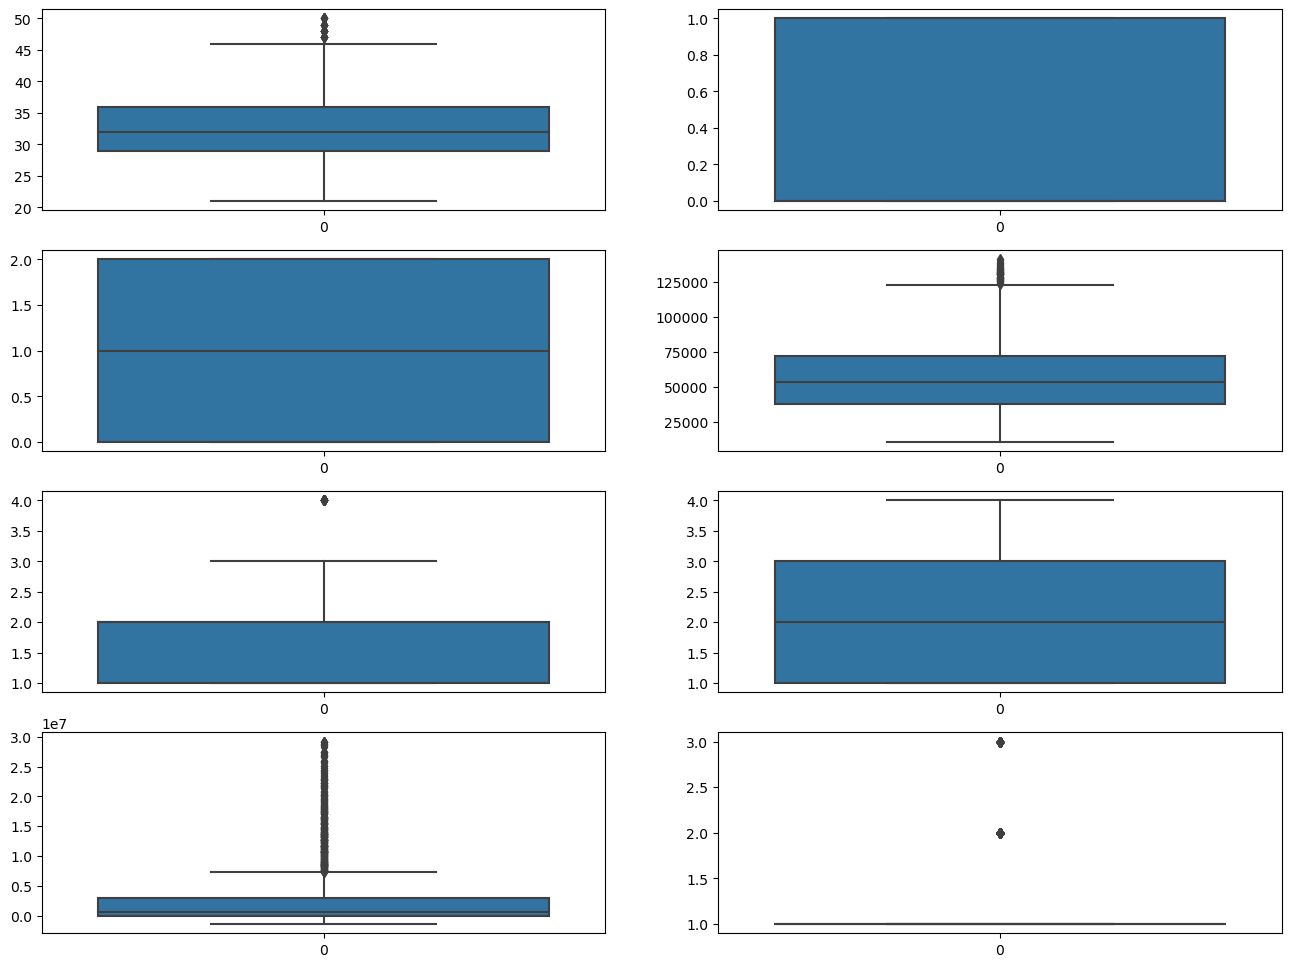

In [168]:

fig, axis = plt.subplots(nrows=4, ncols=2, figsize=(16, 12))

i = 0
for row in range(4):
    for col in range(2):
        sns.boxplot(df_new[num_attri[i]], ax=axis[row, col])
        i += 1
plt.show()

# Coorelation between attributes

C:\Users\smita\AppData\Local\Temp\ipykernel_14644\3416280070.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_new.corr(method='spearman'), annot=True, cmap='Blues')


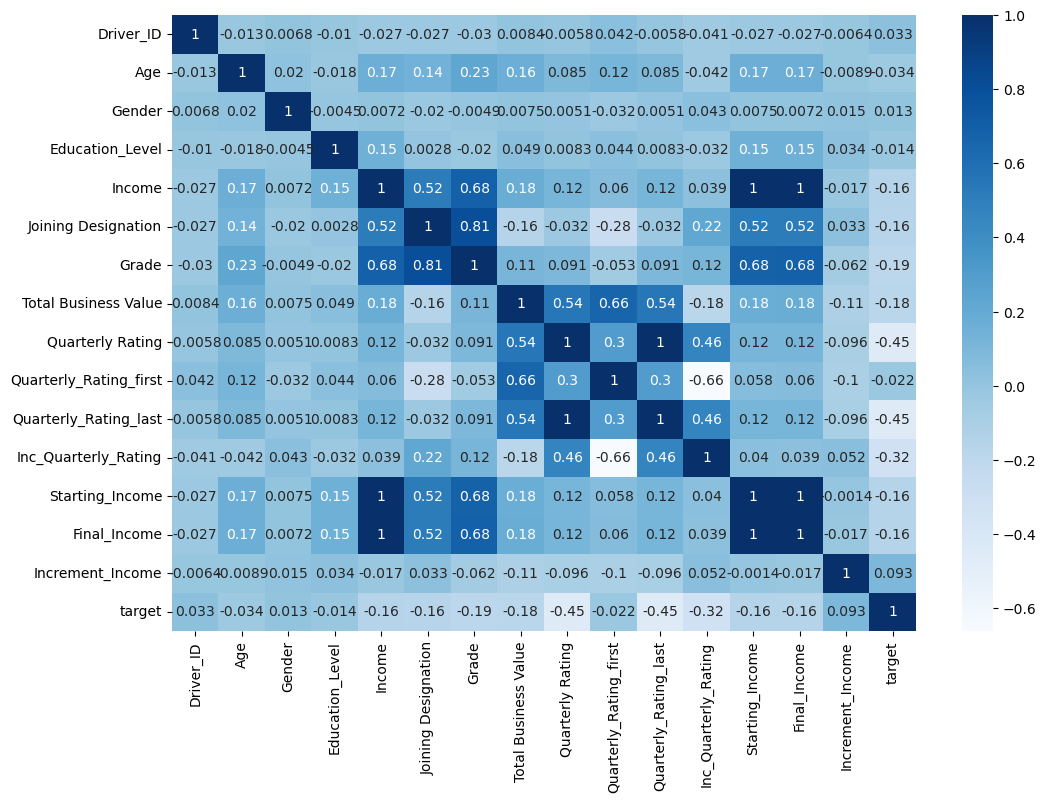

In [169]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df_new.corr(method='spearman'), annot=True, cmap='Blues') 
plt.show()

# Encoding

In [170]:
import category_encoders as ce
tenc=ce.TargetEncoder() 
df_city=tenc.fit_transform(df_new['City'],df_new['Income'])

df_final = df_city.join(df_new.drop('City',axis = 1))
df_final

,City,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly_Rating_first,Quarterly_Rating_last,Inc_Quarterly_Rating,Starting_Income,Final_Income,Increment_Income,target
0,58703.352343,1,28.0,0.0,2,57387,1,1,1715580,2,2,2,0,57387,57387,0,1
1,58448.338420,2,31.0,0.0,2,67016,2,2,0,1,1,1,0,67016,67016,0,0
2,52264.379394,4,43.0,0.0,2,65603,2,2,350000,1,1,1,0,65603,65603,0,1
3,56610.006907,5,29.0,0.0,0,46368,1,1,120360,1,1,1,0,46368,46368,0,1
4,63048.979006,6,31.0,1.0,1,78728,3,3,1265000,2,1,2,1,78728,78728,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2375,52896.679299,2782,26.0,0.0,1,29582,1,1,0,1,1,1,0,29582,29582,0,1
2377,56610.006907,2785,34.0,1.0,0,12105,1,1,0,1,1,1,0,12105,12105,0,1
2378,52896.679299,2786,44.0,0.0,0,35370,2,2,2815090,1,2,1,-1,35370,35370,0,1
2379,59145.382737,2787,28.0,1.0,2,69498,1,1,977830,1,2,1,-1,69498,69498,0,1


# KNN Imputation

In [ ]:
# Imputing with KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')

df_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_new), columns=df_new.columns)

# Data Preparation for Modeling

In [172]:
X = df_final.drop('target', axis=1) 
y = df_final['target']

In [173]:
from sklearn.preprocessing import StandardScaler


### Split the data

In [174]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=0)

### Standardization

In [175]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Bagging and Boosting Modeling and Result Evaluation

In [176]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import model_selection
from sklearn.metrics import accuracy_score

seed = 7
kfold = model_selection.KFold(n_splits=10)
dt = DecisionTreeClassifier(random_state=22)
num_trees = 100

dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)
y_pred_train=dt.predict(X_train)
train_accuracy=accuracy_score(y_train,y_pred_train)
test_accuracy=accuracy_score(y_test,y_pred)
print("Training Accuracy:",train_accuracy)
print("Testing Accuracy:",test_accuracy)


Training Accuracy: 1.0
Testing Accuracy: 0.7244525547445255


In [177]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 83,  71],
       [ 80, 314]], dtype=int64)

In [178]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.51      0.54      0.52       154
           1       0.82      0.80      0.81       394

    accuracy                           0.72       548
   macro avg       0.66      0.67      0.66       548
weighted avg       0.73      0.72      0.73       548



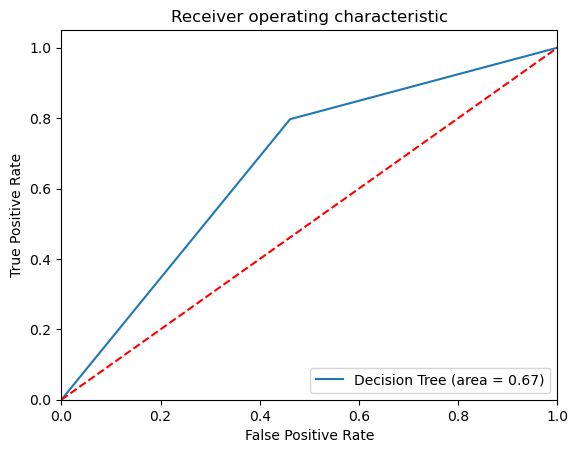

In [179]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
dt_roc_auc = roc_auc_score(y_test, dt.predict(X_test)) 
fpr, tpr, thresholds = roc_curve(y_test, dt.predict_proba(X_test)[:,1]) 
plt.figure()
plt.plot(fpr, tpr, label='Decision Tree (area = %0.2f)' % dt_roc_auc) 
plt.plot([0, 1], [0, 1],'r--') 
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('Receiver operating characteristic') 
plt.legend(loc="lower right") 
plt.savefig('DT_ROC') 
plt.show()

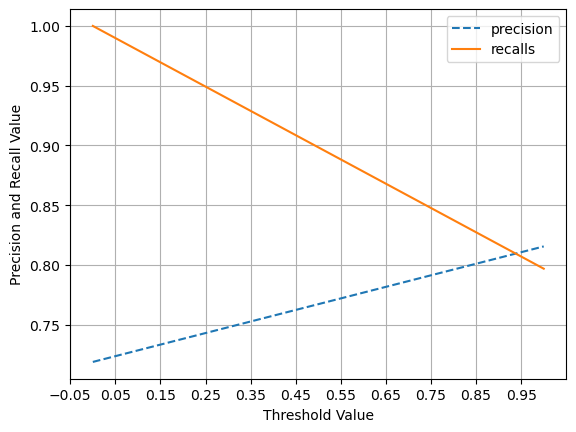

In [180]:
def precision_recall_curve_plot(y_test, pred_proba_c1):    
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)       
    threshold_boundary = thresholds.shape[0] 
    
    # plot precision    
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')  
    
    # plot recall    
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recalls')       
    start, end = plt.xlim()    
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))       
    plt.xlabel('Threshold Value'); plt.ylabel('Precision and Recall Value')    
    plt.legend() 
    plt.grid()    
    plt.show()    
precision_recall_curve_plot(y_test, dt.predict_proba(X_test)[:,1])

In [181]:
model = BaggingClassifier(base_estimator=dt,n_estimators=num_trees, random_state=seed)

results = model_selection.cross_val_score(model, X, y, cv=kfold)
print(results.mean())



C:\Users\smita\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\smita\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\smita\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\smita\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\smita\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\smita\anaconda3\lib\site-p

0.7877812370278123


# Imbalance Treatment

In [182]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())

print('After OverSampling, the shape of train_X: {}'.format(X_train_res.shape)) 
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_res.shape))  
print("After OverSampling, counts of label '1': {}".format(sum(y_train_res == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train_res == 0)))

After OverSampling, the shape of train_X: (2362, 16)
After OverSampling, the shape of train_y: (2362,) 

After OverSampling, counts of label '1': 1181
After OverSampling, counts of label '0': 1181


In [183]:
dt1 = DecisionTreeClassifier(random_state=22)
dt1.fit(X_train_res, y_train_res) 
predictions = dt1.predict(X_test) 

# Classification Report 
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.49      0.60      0.54       154
           1       0.83      0.75      0.79       394

    accuracy                           0.71       548
   macro avg       0.66      0.68      0.66       548
weighted avg       0.73      0.71      0.72       548



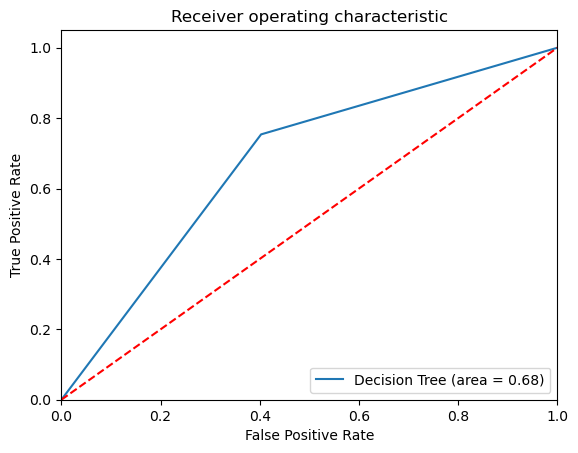

In [184]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
dt1_roc_auc = roc_auc_score(y_test, dt1.predict(X_test)) 
fpr, tpr, thresholds = roc_curve(y_test, dt1.predict_proba(X_test)[:,1]) 
plt.figure()
plt.plot(fpr, tpr, label='Decision Tree (area = %0.2f)' % dt1_roc_auc) 
plt.plot([0, 1], [0, 1],'r--') 
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('Receiver operating characteristic') 
plt.legend(loc="lower right") 
plt.savefig('DT1_ROC') 
plt.show()

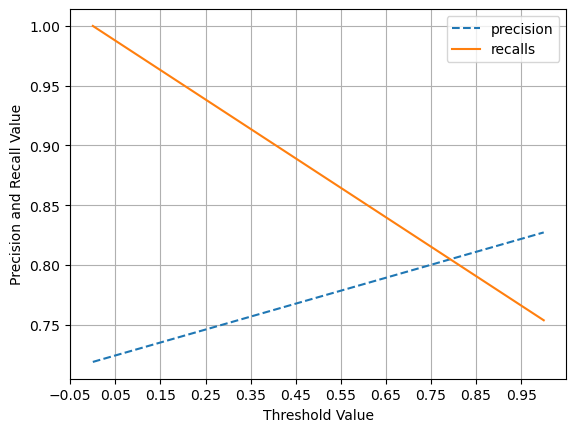

In [185]:
def precision_recall_curve_plot(y_test, pred_proba_c1):    
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)       
    threshold_boundary = thresholds.shape[0] 
    
    # plot precision    
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')  
    
    # plot recall    
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recalls')       
    start, end = plt.xlim()    
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))       
    plt.xlabel('Threshold Value'); 
    plt.ylabel('Precision and Recall Value')    
    plt.legend() 
    plt.grid()    
    plt.show()    
precision_recall_curve_plot(y_test, dt1.predict_proba(X_test)[:,1])

In [186]:
from xgboost import XGBClassifier

xgboost = XGBClassifier(n_estimators = 1000, learning_rate = 0.05)

xgboost.fit(X_train, y_train, early_stopping_rounds = 5, eval_set = [(X_test, y_test)],verbose = False)

score_xgb_train=xgboost.score(X_train,y_train)
score_xgb_test = xgboost.score(X_test,y_test)

print("Training Score:",score_xgb_train)
print("Testing Score:",score_xgb_test)

y_pred=xgboost.predict(X_test)

xgb_cm=confusion_matrix(y_pred,y_test)
xgb_report=classification_report(y_pred,y_test)

print(xgb_cm)
print(xgb_report)

C:\Users\smita\anaconda3\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Training Score: 0.8636640292148509
Testing Score: 0.7974452554744526
[[ 71  28]
 [ 83 366]]
              precision    recall  f1-score   support

           0       0.46      0.72      0.56        99
           1       0.93      0.82      0.87       449

    accuracy                           0.80       548
   macro avg       0.69      0.77      0.71       548
weighted avg       0.84      0.80      0.81       548



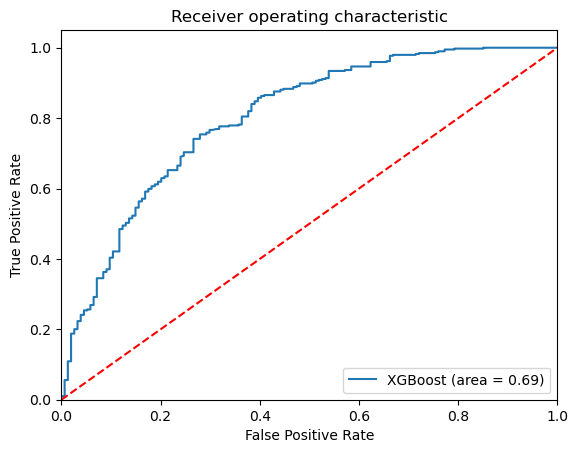

In [187]:

xgb_roc_auc = roc_auc_score(y_test, xgboost.predict(X_test)) 
fpr, tpr, thresholds = roc_curve(y_test, xgboost.predict_proba(X_test)[:,1]) 
plt.figure()
plt.plot(fpr, tpr, label='XGBoost (area = %0.2f)' % xgb_roc_auc) 
plt.plot([0, 1], [0, 1],'r--') 
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('Receiver operating characteristic') 
plt.legend(loc="lower right") 
plt.savefig('XGBOOST_ROC') 
plt.show()

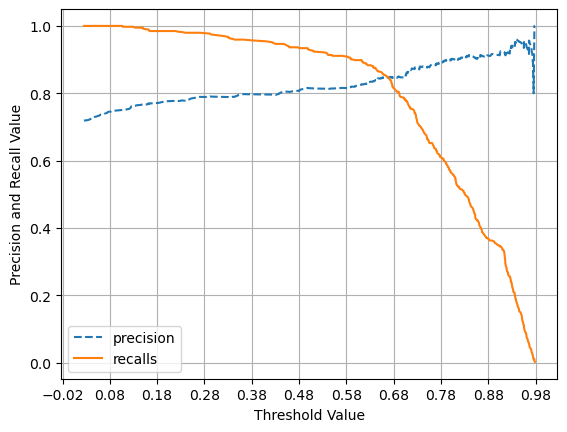

In [188]:
def precision_recall_curve_plot(y_test, pred_proba_c1):    
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)       
    threshold_boundary = thresholds.shape[0] 
    
    # plot precision    
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')  
    
    # plot recall    
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recalls')       
    start, end = plt.xlim()    
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))       
    plt.xlabel('Threshold Value'); 
    plt.ylabel('Precision and Recall Value')    
    plt.legend() 
    plt.grid()    
    plt.show()    
precision_recall_curve_plot(y_test, xgboost.predict_proba(X_test)[:,1])

# Insights and Recommendation

## Insights
 1. The number of male drivers  are more in number as compared to female driver.
 2. More numbers of ola drivers are graduate. 
 3.It is observed form 'Joining Designation' that senior ola drivers are less in number as compared to the new joiners.
 4. The highest grade value is 5 and lowest grade value is 2. The numbers of ola drivers belonging to grade 5 are very less in numbers i.e. 24 . The number of ola drivers belonging to grade 2 is highest in numbers i.e. 855.
 5. The number of ola drivers belonging to highest quaterly rating 4 is 107 in numbers where as the number of ola drivers belonging to lowest quartely rating 1 is 1744 in numbers.
 6. The target variable obtained from feature engineering has shown that the number of ola drivers leaving the company is more i.e. 1616  in numbers as compared to staying in the company i.e. 765 in numbers.  
 7. More numbers of drivers have not got any increment in their income and quaterly rating.
    
## Recommendations
 1. The number of seniormost dribers are less as compared to new drivers so ola company should facilitate job security to the senior drivers by providing pension scheme, education facilities to their children, and medical facilities to retain them in the company.
 2. The highest quaterly rating to the driver is 4 and the driver with 4 rating is less in number, company should track the parameters on which the drivers have got such rating and on the basis of that ola should provide highest increment and bonus to them to retain them.
 3. The company should focus on the parameters on which the  driver has got less rating and do counselling of them to provide improvement in the rating . The comapny should provide highest increment on the basis of improvement so that drivers can think about staying in the company .
 4. Company should also focus on hiring female drivers and also provide secure environment of driving to them to increase their numbers in the company.
 5. Ola should work out on their increment policy to retain more number of drivers.
